<div style="text-align:center; border-radius:15px 50px; padding:22px; color:white; background-color:#000080; font-family:Pacifico">
<h1 style="color:white; margin:0; font-size:230%">Air Quality Data Analysis</h1>
<h3 style="color:#c9d4ff; margin-top:10px; font-family:Arial">Hourly Readings Across 6 Cities, 2024 &nbsp;|&nbsp; PRG-330 Final Project</h3>
<p style="color:#ffffff; font-family:Arial; font-size:110%; margin-top:16px; margin-bottom:0">
<b>Team:</b> &nbsp; Aaska &nbsp;&middot;&nbsp; Aishmita &nbsp;&middot;&nbsp; Anupam
</p>
</div>


### How we divided the work

We split the notebook into three parts so that each of us presents our own section.

| Part | What it covers | Presented by |
| :---- | :---- | :---- |
| **Part 1** | Variables and data types, operators, conditional statements, and loops (Modules 1-3) | **Aaska** |
| **Part 2** | Functions, basic file I/O, and the full Pandas analysis, including the missing-CO2 investigation (Modules 4-6) | **Aishmita** |
| **Part 3** | NumPy analysis, Matplotlib visualizations, and the findings/conclusion (Modules 7-8) | **Anupam** |

We picked the dataset and agreed on the questions together first, then each of us wrote our own
part. At the end we read through the whole notebook as a group and checked every number in the
findings section against what the code actually prints.

**Dataset:** `Air_Quality.csv` -- hourly air-quality readings for 6 cities (Brasilia, Cairo, Dubai,
London, New York, Sydney), all of 2024. Columns: `Date`, `City`, `CO`, `CO2`, `NO2`, `SO2`, `O3`,
`PM2.5`, `PM10`, `AQI`.


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #000080; overflow:hidden"><b>Part 1: Python fundamentals</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aaska</div></div>

### Module 1: variables and data types

**Why we start here.** Our professor wants to see plain Python before any library does the work
for us, so before touching Pandas we pull one real observation from the dataset apart by hand and
store each field in its own variable. That is also the easiest way to look at the basic types
Python gives us: `str`, `float`, `int`, and `bool`.

The record below is real -- Sydney, 31 December 2024, 23:00.


In [1]:
# One real record from the dataset, stored as individual variables
record_date = "2024-12-31 23:00"   # str  -> text/date information
record_city = "Sydney"             # str  -> category / label

co_level   = 107.0   # float -> Carbon Monoxide (ppb)
co2_level  = 443.0   # float -> Carbon Dioxide (ppm)
no2_level  = 7.8      # float -> Nitrogen Dioxide (ppb)
so2_level  = 11.3     # float -> Sulfur Dioxide (ppb)
o3_level   = 74.0     # float -> Ozone (ppb)
pm25_level = 12.6     # float -> Fine particulate matter
pm10_level = 17.1     # float -> Coarse particulate matter
aqi_value  = 29.6     # float -> Air Quality Index

record_count = 52704  # int   -> total rows in the raw CSV (all cities, all hours)

is_high_pollution_day = False  # bool -> we will set this properly with a real condition in Module 2

print(record_date, record_city, aqi_value)


2024-12-31 23:00 Sydney 29.6


**Checking our work.** `type()` confirms Python picked the types we expected.

In [2]:
print("type of record_city  :", type(record_city))
print("type of aqi_value    :", type(aqi_value))
print("type of record_count :", type(record_count))
print("type of is_high_pollution_day :", type(is_high_pollution_day))


type of record_city  : <class 'str'>
type of aqi_value    : <class 'float'>
type of record_count : <class 'int'>
type of is_high_pollution_day : <class 'bool'>


**Bundling a record together.** A dictionary lets us keep one full observation as a single
variable instead of nine separate ones. This is the shape we will reuse for every sample record
for the rest of Part 1 and into Aishmita's Part 2.


In [3]:
sydney_record = {
    "date": record_date,
    "city": record_city,
    "CO": co_level,
    "CO2": co2_level,
    "NO2": no2_level,
    "SO2": so2_level,
    "O3": o3_level,
    "PM2.5": pm25_level,
    "PM10": pm10_level,
    "AQI": aqi_value,
}

print(sydney_record)
print("Number of fields in this record:", len(sydney_record))


{'date': '2024-12-31 23:00', 'city': 'Sydney', 'CO': 107.0, 'CO2': 443.0, 'NO2': 7.8, 'SO2': 11.3, 'O3': 74.0, 'PM2.5': 12.6, 'PM10': 17.1, 'AQI': 29.6}
Number of fields in this record: 10


### Module 2: operators and conditional statements

**What we need a second record for.** Comparing Sydney to itself does not show off comparison
operators very well, so we bring in the single worst reading in the entire dataset -- Dubai, 18
August 2024, 04:00, AQI about 196.6 -- and use the two records together.


In [4]:
dubai_record = {
    "date": "2024-08-18 04:00",
    "city": "Dubai",
    "CO": 229.0,
    "CO2": None,     # not recorded yet at this point in the year -- Aishmita explains why in Part 2
    "NO2": 21.0,
    "SO2": 10.8,
    "O3": 51.0,
    "PM2.5": 65.9,
    "PM10": 391.2,
    "AQI": 196.63,
}

print(dubai_record)


{'date': '2024-08-18 04:00', 'city': 'Dubai', 'CO': 229.0, 'CO2': None, 'NO2': 21.0, 'SO2': 10.8, 'O3': 51.0, 'PM2.5': 65.9, 'PM10': 391.2, 'AQI': 196.63}


**Arithmetic operators.** Basic math on the two records.

In [5]:
pm_total      = sydney_record["PM2.5"] + sydney_record["PM10"]     # addition
pm_difference = dubai_record["PM10"] - dubai_record["PM2.5"]       # subtraction
aqi_doubled   = sydney_record["AQI"] * 2                           # multiplication
aqi_half      = dubai_record["AQI"] / 2                            # division
aqi_whole     = int(dubai_record["AQI"]) % 50                      # modulus (remainder)

print("Sydney PM2.5 + PM10        :", pm_total)
print("Dubai PM10 - PM2.5         :", pm_difference)
print("Sydney AQI doubled         :", aqi_doubled)
print("Dubai AQI halved           :", aqi_half)
print("Dubai AQI (int) mod 50     :", aqi_whole)


Sydney PM2.5 + PM10        : 29.700000000000003
Dubai PM10 - PM2.5         : 325.29999999999995
Sydney AQI doubled         : 59.2
Dubai AQI halved           : 98.315
Dubai AQI (int) mod 50     : 46


**Comparison operators.** These all return `True` or `False`.

In [6]:
print("Dubai AQI > Sydney AQI ?     ", dubai_record["AQI"] > sydney_record["AQI"])
print("Sydney AQI == 29.6 ?         ", sydney_record["AQI"] == 29.6)
print("Dubai PM10 >= 100 ?          ", dubai_record["PM10"] >= 100)
print("Sydney city != Dubai city ?  ", sydney_record["city"] != dubai_record["city"])


Dubai AQI > Sydney AQI ?      True
Sydney AQI == 29.6 ?          True
Dubai PM10 >= 100 ?           True
Sydney city != Dubai city ?   True


**Logical operators.** `and`, `or`, and `not` let us combine more than one condition at once.

In [7]:
dubai_pm25_high = dubai_record["PM2.5"] > 35
dubai_pm10_high = dubai_record["PM10"] > 100

both_high = dubai_pm25_high and dubai_pm10_high
either_high = dubai_pm25_high or dubai_pm10_high
sydney_not_polluted = not (sydney_record["AQI"] > 100)

print("Dubai PM2.5 high AND PM10 high :", both_high)
print("Dubai PM2.5 high OR PM10 high  :", either_high)
print("Sydney is NOT heavily polluted :", sydney_not_polluted)


Dubai PM2.5 high AND PM10 high : True
Dubai PM2.5 high OR PM10 high  : True
Sydney is NOT heavily polluted : True


**Assignment operators.** `+=` and `*=` update a variable using its own current value.

In [8]:
running_total = 0
running_total += sydney_record["AQI"]
running_total += dubai_record["AQI"]

running_total_scaled = running_total
running_total_scaled *= 10

print("Running total AQI (Sydney + Dubai):", running_total)
print("Running total AQI scaled x10      :", running_total_scaled)


Running total AQI (Sydney + Dubai): 226.23
Running total AQI scaled x10      : 2262.2999999999997


**Classifying AQI with `if` / `elif` / `else`.** We use the standard AQI breakpoints (Good up to
50, Moderate up to 100, Unhealthy for Sensitive Groups up to 150, Unhealthy up to 200, and so on)
and run both records through the same logic.


In [9]:
aqi = sydney_record["AQI"]

if aqi <= 50:
    category = "Good"
elif aqi <= 100:
    category = "Moderate"
elif aqi <= 150:
    category = "Unhealthy for Sensitive Groups"
elif aqi <= 200:
    category = "Unhealthy"
elif aqi <= 300:
    category = "Very Unhealthy"
else:
    category = "Hazardous"

print(f"Sydney AQI = {aqi} -> category: {category}")


Sydney AQI = 29.6 -> category: Good


In [10]:
aqi = dubai_record["AQI"]

if aqi <= 50:
    category = "Good"
elif aqi <= 100:
    category = "Moderate"
elif aqi <= 150:
    category = "Unhealthy for Sensitive Groups"
elif aqi <= 200:
    category = "Unhealthy"
elif aqi <= 300:
    category = "Very Unhealthy"
else:
    category = "Hazardous"

print(f"Dubai AQI = {aqi} -> category: {category}")

# Also flag a "higher-pollution condition" using PM2.5 and PM10 together
if dubai_record["PM2.5"] > 35 and dubai_record["PM10"] > 150:
    print("This record shows a higher-pollution condition (both PM2.5 and PM10 elevated).")
else:
    print("This record does not show elevated particulate pollution on both fronts.")


Dubai AQI = 196.63 -> category: Unhealthy
This record shows a higher-pollution condition (both PM2.5 and PM10 elevated).


**What we found.** Sydney lands in "Good" and Dubai lands in "Unhealthy" with both particulate
flags tripped -- which makes sense, since we deliberately picked Dubai's worst hour of the whole
year to test the logic against.


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #191970; overflow:hidden"><b>Part 1 continued: loops</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aaska</div></div>

### Module 3: loops

**Why we need a bigger sample.** One record at a time was fine for showing off operators, but
loops are only useful once there is more than one thing to loop over. We picked 12 real records
directly from the CSV -- two per city, one from February and one from late December -- and typed
them in as a list of dictionaries. We are not reading the actual file yet; Aishmita does real file
reading with `open()` in Module 5.


In [11]:
sample_records = [
    {"date": "2024-02-11 16:00", "city": "Brasilia", "CO": 176.0, "CO2": None,  "NO2": 1.9,  "SO2": 0.7,  "O3": 45.0, "PM2.5": 2.7,  "PM10": 3.6,   "AQI": 18.0},
    {"date": "2024-12-29 22:00", "city": "Brasilia", "CO": 343.0, "CO2": 442.0, "NO2": 13.2, "SO2": 2.4,  "O3": 75.0, "PM2.5": 10.0, "PM10": 10.2,  "AQI": 30.0},
    {"date": "2024-02-11 16:00", "city": "Cairo",    "CO": 476.0, "CO2": None,  "NO2": 65.9, "SO2": 34.4, "O3": 39.0, "PM2.5": 33.1, "PM10": 42.9,  "AQI": 66.2},
    {"date": "2024-12-29 22:00", "city": "Cairo",    "CO": 415.0, "CO2": 457.0, "NO2": 47.9, "SO2": 50.1, "O3": 13.0, "PM2.5": 23.2, "PM10": 34.2,  "AQI": 49.6},
    {"date": "2024-02-11 16:00", "city": "Dubai",    "CO": 381.0, "CO2": None,  "NO2": 58.1, "SO2": 17.7, "O3": 31.0, "PM2.5": 55.9, "PM10": 179.3, "AQI": 82.1},
    {"date": "2024-12-29 22:00", "city": "Dubai",    "CO": 524.0, "CO2": 460.0, "NO2": 29.8, "SO2": 17.0, "O3": 85.0, "PM2.5": 31.9, "PM10": 51.1,  "AQI": 68.9},
    {"date": "2024-02-11 16:00", "city": "London",   "CO": 192.0, "CO2": None,  "NO2": 14.7, "SO2": 2.3,  "O3": 48.0, "PM2.5": 10.5, "PM10": 16.6,  "AQI": 30.3},
    {"date": "2024-12-29 22:00", "city": "London",   "CO": 188.0, "CO2": 468.0, "NO2": 35.1, "SO2": 3.2,  "O3": 28.0, "PM2.5": 12.1, "PM10": 16.6,  "AQI": 27.5},
    {"date": "2024-02-11 16:00", "city": "New York",  "CO": 265.0, "CO2": None, "NO2": 20.1, "SO2": 5.7,  "O3": 32.0, "PM2.5": 10.0, "PM10": 14.6,  "AQI": 33.1},
    {"date": "2024-12-29 22:00", "city": "New York",  "CO": 190.0, "CO2": 457.0,"NO2": 27.4, "SO2": 3.5,  "O3": 64.0, "PM2.5": 10.7, "PM10": 14.4,  "AQI": 51.9},
    {"date": "2024-02-11 16:00", "city": "Sydney",   "CO": 101.0, "CO2": None,  "NO2": 22.5, "SO2": 8.3,  "O3": 10.0, "PM2.5": 12.2, "PM10": 20.3,  "AQI": 22.1},
    {"date": "2024-12-29 22:00", "city": "Sydney",   "CO": 85.0,  "CO2": 436.0, "NO2": 6.3,  "SO2": 2.4,  "O3": 49.0, "PM2.5": 6.9,  "PM10": 10.2,  "AQI": 19.6},
]

print("Loaded", len(sample_records), "sample records")


Loaded 12 sample records


**A basic `for` loop.** Counting records and adding up AQI by hand.

In [12]:
record_total = 0
aqi_sum = 0.0

for rec in sample_records:
    record_total += 1
    aqi_sum += rec["AQI"]

print("Records processed:", record_total)
print("Sum of AQI values :", round(aqi_sum, 2))


Records processed: 12
Sum of AQI values : 499.3


**A loop with a condition inside.** Flagging every sample record above AQI 50 as we go.

In [13]:
high_aqi_count = 0

for rec in sample_records:
    if rec["AQI"] > 50:
        high_aqi_count += 1
        print(f"High-AQI record -> {rec['city']} on {rec['date']}: AQI = {rec['AQI']}")

print()
print("Total high-AQI (>50) records:", high_aqi_count, "out of", len(sample_records))


High-AQI record -> Cairo on 2024-02-11 16:00: AQI = 66.2
High-AQI record -> Dubai on 2024-02-11 16:00: AQI = 82.1
High-AQI record -> Dubai on 2024-12-29 22:00: AQI = 68.9
High-AQI record -> New York on 2024-12-29 22:00: AQI = 51.9

Total high-AQI (>50) records: 4 out of 12


**Finding the worst record without `max()`.** Just a loop and a comparison.

In [14]:
worst_record = sample_records[0]

for rec in sample_records:
    if rec["AQI"] > worst_record["AQI"]:
        worst_record = rec

print("Most polluted sample record:")
print(worst_record)


Most polluted sample record:
{'date': '2024-02-11 16:00', 'city': 'Dubai', 'CO': 381.0, 'CO2': None, 'NO2': 58.1, 'SO2': 17.7, 'O3': 31.0, 'PM2.5': 55.9, 'PM10': 179.3, 'AQI': 82.1}


**A `while` loop.** Stops as soon as it finds the first record with a missing CO2 value.

In [15]:
index = 0
found_missing_co2 = False

while index < len(sample_records) and not found_missing_co2:
    if sample_records[index]["CO2"] is None:
        found_missing_co2 = True
        print(f"First record with missing CO2 -> {sample_records[index]['city']} on {sample_records[index]['date']}")
    index += 1


First record with missing CO2 -> Brasilia on 2024-02-11 16:00


**Handing off to Aishmita.** That last loop is not an accident -- six of our twelve sample records
have no CO2 value. It turns out that is true of the real dataset too, and a big part, which
Aishmita digs into properly with Pandas in Part 2.


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #4B0082; overflow:hidden"><b>Part 2: functions and file I/O</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aishmita</div></div>

### Module 4: functions

**What we are reusing.** Aaska's Module 2 classified one AQI value by hand with `if` / `elif` /
`else`, and Module 3 added up a list of AQI values with a loop. Writing that logic out every time
gets old fast, so we wrap it into functions and call them on `sample_records`.


In [16]:
def calculate_total(values):
    """Add up a list of numbers using a loop."""
    total = 0
    for v in values:
        total += v
    return total


def calculate_average(values):
    """Return the average of a list of numbers."""
    if len(values) == 0:
        return 0
    return calculate_total(values) / len(values)


def classify_aqi(aqi):
    """Return the EPA-style category name for a given AQI value."""
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"


def is_high_pollution(pm25, pm10, pm25_limit=35, pm10_limit=150):
    """Return True when both PM2.5 and PM10 exceed the given limits."""
    return pm25 > pm25_limit and pm10 > pm10_limit


**Calling the total/average functions** on the AQI values from Aaska's 12 sample records.

In [17]:
aqi_values = [rec["AQI"] for rec in sample_records]

total_aqi = calculate_total(aqi_values)
average_aqi = calculate_average(aqi_values)

print("AQI values          :", aqi_values)
print("Total AQI            :", round(total_aqi, 2))
print("Average AQI           :", round(average_aqi, 2))


AQI values          : [18.0, 30.0, 66.2, 49.6, 82.1, 68.9, 30.3, 27.5, 33.1, 51.9, 22.1, 19.6]
Total AQI            : 499.3
Average AQI           : 41.61


**Calling `classify_aqi` and `is_high_pollution`** on every sample record at once.

In [18]:
for rec in sample_records:
    category = classify_aqi(rec["AQI"])
    high_pollution = is_high_pollution(rec["PM2.5"], rec["PM10"])
    print(f"{rec['city']:10s} {rec['date']}  AQI={rec['AQI']:6.1f}  category={category:30s}  high_pollution={high_pollution}")


Brasilia   2024-02-11 16:00  AQI=  18.0  category=Good                            high_pollution=False
Brasilia   2024-12-29 22:00  AQI=  30.0  category=Good                            high_pollution=False
Cairo      2024-02-11 16:00  AQI=  66.2  category=Moderate                        high_pollution=False
Cairo      2024-12-29 22:00  AQI=  49.6  category=Good                            high_pollution=False
Dubai      2024-02-11 16:00  AQI=  82.1  category=Moderate                        high_pollution=True
Dubai      2024-12-29 22:00  AQI=  68.9  category=Moderate                        high_pollution=False
London     2024-02-11 16:00  AQI=  30.3  category=Good                            high_pollution=False
London     2024-12-29 22:00  AQI=  27.5  category=Good                            high_pollution=False
New York   2024-02-11 16:00  AQI=  33.1  category=Good                            high_pollution=False
New York   2024-12-29 22:00  AQI=  51.9  category=Moderate                

### Module 5: basic file I/O

**Before Pandas does it for us.** The course covers plain file handling before Pandas, so we read
the real `Air_Quality.csv` with `open()` / `with open()` and write our own short summary out to a
text file, all without a single Pandas function.


In [19]:
csv_path = "Air_Quality.csv"

with open(csv_path, "r") as file:
    header_line = file.readline()
    first_data_line = file.readline()

print("Header line:", header_line.strip())
print("First data line:", first_data_line.strip())


Header line: Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
First data line: 2024-01-01 00:00:00+00:00,Brasilia,323.0,,23.8,2.8,42.0,12.0,17.1,16.8


**Processing real rows with a loop.** We read the first 2000 data lines and total up the AQI column ourselves.

In [20]:
line_count = 0
aqi_column_index = 9  # AQI is the 10th column (index 9)
total_aqi_from_file = 0.0

with open(csv_path, "r") as file:
    header = file.readline()  # skip header
    for line in file:
        if line_count >= 2000:
            break
        fields = line.strip().split(",")
        total_aqi_from_file += float(fields[aqi_column_index])
        line_count += 1

average_aqi_from_file = total_aqi_from_file / line_count

print("Lines read (excluding header):", line_count)
print("Total AQI from first 2000 rows  :", round(total_aqi_from_file, 2))
print("Average AQI from first 2000 rows:", round(average_aqi_from_file, 2))


Lines read (excluding header): 2000
Total AQI from first 2000 rows  : 40763.12
Average AQI from first 2000 rows: 20.38


**Writing our own output file**, then reading it back to prove it saved correctly.

In [21]:
output_path = "file_io_summary.txt"

with open(output_path, "w") as out_file:
    out_file.write("Air Quality Project -- File I/O Summary\n")
    out_file.write("========================================\n")
    out_file.write(f"Sample records analyzed (Module 3/4): {len(sample_records)}\n")
    out_file.write(f"Average AQI of sample records: {round(average_aqi, 2)}\n")
    out_file.write(f"Lines read directly from CSV: {line_count}\n")
    out_file.write(f"Average AQI of first {line_count} CSV rows: {round(average_aqi_from_file, 2)}\n")

with open(output_path, "r") as in_file:
    print(in_file.read())


Air Quality Project -- File I/O Summary
Sample records analyzed (Module 3/4): 12
Average AQI of sample records: 41.61
Lines read directly from CSV: 2000
Average AQI of first 2000 CSV rows: 20.38



# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #000080; overflow:hidden"><b>Part 2 continued: the Pandas analysis</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Aishmita</div></div>

### Module 6: Pandas analysis

**Why we switch to Pandas now.** Reading 2000 lines by hand in Module 5 worked, but the real file
has 52,704 rows across six cities -- not something we want to loop over by hand. Pandas loads the
whole thing at once and gives us `shape`, `groupby`, and everything else we need for the real
analysis.


In [22]:
import pandas as pd

df = pd.read_csv("Air_Quality.csv")
df.head()


,Date,City,CO,CO2,NO2,SO2,O3,PM2.5,PM10,AQI
0,2024-01-01 00:00:00+00:00,Brasilia,323.0,NaN,23.8,2.8,42.0,12.0,17.1,16.800000
1,2024-01-01 01:00:00+00:00,Brasilia,318.0,NaN,21.9,2.7,40.0,12.5,17.9,16.000000
2,2024-01-01 02:00:00+00:00,Brasilia,309.0,NaN,19.2,2.6,39.0,12.1,17.3,15.599999
3,2024-01-01 03:00:00+00:00,Brasilia,295.0,NaN,16.3,2.4,38.0,11.4,16.2,15.200000
4,2024-01-01 04:00:00+00:00,Brasilia,270.0,NaN,13.0,2.1,40.0,10.2,14.6,16.000000


In [23]:
print("Shape (rows, columns):", df.shape)
print()
print("Columns:", list(df.columns))
print()
print("Data types:")
print(df.dtypes)


Shape (rows, columns): (52704, 10)

Columns: ['Date', 'City', 'CO', 'CO2', 'NO2', 'SO2', 'O3', 'PM2.5', 'PM10', 'AQI']

Data types:
Date         str
City         str
CO       float64
CO2      float64
NO2      float64
SO2      float64
O3       float64
PM2.5    float64
PM10     float64
AQI      float64
dtype: object


**Checking for missing values** across every column.

In [24]:
missing_counts = df.isnull().sum()
missing_percent = (missing_counts / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_percent,
})
missing_summary


,missing_count,missing_percent
Date,0,0.00
City,0,0.00
CO,0,0.00
CO2,43056,81.69
NO2,0,0.00
SO2,0,0.00
O3,0,0.00
PM2.5,0,0.00
PM10,0,0.00
AQI,0,0.00


**What this shows.** `CO2` is the only column with anything missing, and it is missing in 81.7% of
all rows -- far too much to just fill in and move on. Before deciding what to do about it, we check
*when* the missing values happen, instead of assuming they are scattered randomly.


In [25]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.month

brasilia = df[df["City"] == "Brasilia"]
co2_presence_by_month = brasilia.groupby("Month")["CO2"].apply(lambda col: col.notnull().sum())
co2_total_by_month = brasilia.groupby("Month")["CO2"].size()

co2_pattern = pd.DataFrame({
    "readings_present": co2_presence_by_month,
    "readings_total": co2_total_by_month,
})
co2_pattern


,readings_present,readings_total
Month,,
1,0,744
2,0,696
3,0,744
4,0,720
5,0,744
6,0,720
7,0,744
8,0,744
9,0,720


**What we found.** CO2 has zero readings from January through most of October, then becomes
essentially complete from late October onward -- a monitoring change that started on **26 October
2024**, the same date across every single city. This is a **structural gap**, not a handful of
random sensor dropouts, so filling it in with 0, the column average, or interpolation across the
whole year would fabricate ten months of data that were never actually measured.

**Our decision.** We do not invent CO2 values for January through October. Instead:
- CO2 is only reported and used for the period where it was genuinely measured (26 Oct 2024 onward).
- Every other pollutant (CO, NO2, SO2, O3, PM2.5, PM10) and AQI is complete for the full year, and
  those are what drive the city/time analysis below.


In [26]:
co2_available = df[df["CO2"].notnull()]
print("Earliest CO2 reading :", co2_available["Date"].min())
print("Latest CO2 reading   :", co2_available["Date"].max())
print("Rows with usable CO2 :", len(co2_available), f"({len(co2_available)/len(df)*100:.1f}% of all rows)")
print()
print("Average CO2 (Oct 26 - Dec 31 only), by city:")
co2_available.groupby("City")["CO2"].mean().round(1)


Earliest CO2 reading : 2024-10-26 00:00:00+00:00
Latest CO2 reading   : 2024-12-31 23:00:00+00:00
Rows with usable CO2 : 9648 (18.3% of all rows)

Average CO2 (Oct 26 - Dec 31 only), by city:


City
Brasilia    445.7
Cairo       457.9
Dubai       463.8
London      475.1
New York    488.4
Sydney      443.2
Name: CO2, dtype: float64

**One more thing worth noticing.** In this two-month window New York has the highest average CO2
and Sydney the lowest -- a different ranking than the AQI ranking we get below for the full year.
That is one more reason not to stretch CO2 conclusions over months we never actually measured.


**Filtering.** Every hour where AQI reaches at least "Unhealthy for Sensitive Groups" (AQI > 100).

In [27]:
high_aqi_df = df[df["AQI"] > 100]
print("Hours with AQI > 100:", len(high_aqi_df), f"out of {len(df)} ({len(high_aqi_df)/len(df)*100:.2f}%)")
high_aqi_df[["Date", "City", "AQI", "PM2.5", "PM10"]].sort_values("AQI", ascending=False).head(10)


Hours with AQI > 100: 2182 out of 52704 (4.14%)


,Date,City,AQI,PM2.5,PM10
23092,2024-08-18 04:00:00+00:00,Dubai,196.63333,65.9,391.2
23091,2024-08-18 03:00:00+00:00,Dubai,196.41666,59.3,339.0
23093,2024-08-18 05:00:00+00:00,Dubai,195.93500,70.8,443.3
23090,2024-08-18 02:00:00+00:00,Dubai,195.22168,53.0,314.8
23094,2024-08-18 06:00:00+00:00,Dubai,195.19000,69.6,452.6
23103,2024-08-18 15:00:00+00:00,Dubai,194.91167,52.4,271.0
23104,2024-08-18 16:00:00+00:00,Dubai,194.89668,53.4,278.5
23095,2024-08-18 07:00:00+00:00,Dubai,194.80164,64.7,431.2
23096,2024-08-18 08:00:00+00:00,Dubai,194.41333,60.1,412.6
23102,2024-08-18 14:00:00+00:00,Dubai,194.27502,52.6,276.6


**What jumps out.** Every single one of the top 10 worst hours is Dubai on 18 August -- the same
event we picked out by hand in Aaska's Part 1. It is not spread across the year; it is one event.


**Grouping by city.** Average pollutant levels and AQI, city by city.

In [28]:
city_summary = df.groupby("City")[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10", "AQI"]].mean().round(2)
city_summary = city_summary.sort_values("AQI", ascending=False)
city_summary


,CO,NO2,SO2,O3,PM2.5,PM10,AQI
City,,,,,,,
Dubai,440.46,39.49,20.31,93.88,41.57,111.04,85.11
Cairo,293.82,32.62,38.29,61.10,23.74,43.42,52.49
New York,283.64,27.80,6.25,52.12,13.36,18.95,32.88
London,187.74,21.80,3.33,49.15,9.99,14.14,27.10
Sydney,122.43,14.17,5.62,46.14,10.94,17.42,25.77
Brasilia,221.45,8.74,1.62,57.76,6.55,8.89,24.75


**Date/time analysis.** Average AQI by month, across all six cities.

In [29]:
monthly_aqi = df.groupby("Month")["AQI"].mean().round(2)
monthly_aqi


Month
1     39.45
2     39.24
3     41.76
4     40.83
5     40.24
6     40.66
7     46.81
8     48.33
9     43.84
10    35.85
11    38.21
12    40.78
Name: AQI, dtype: float64

**Handing off to Anupam.** `city_summary` and `monthly_aqi` are the two tables Anupam turns into
charts in Part 3, and the arrays below feed straight into NumPy.


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #191970; overflow:hidden"><b>Part 3: NumPy and visualization</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Anupam</div></div>

### Module 7: NumPy analysis

**Picking up from Aishmita's DataFrame.** `df` already has everything we need, so we pull the key
pollutant columns out as NumPy arrays and compute summary statistics and comparisons directly with
NumPy instead of Pandas' built-in methods.


In [30]:
import numpy as np

aqi_array  = df["AQI"].to_numpy()
pm25_array = df["PM2.5"].to_numpy()
pm10_array = df["PM10"].to_numpy()
co_array   = df["CO"].to_numpy()
no2_array  = df["NO2"].to_numpy()
so2_array  = df["SO2"].to_numpy()
o3_array   = df["O3"].to_numpy()

print("AQI array shape:", aqi_array.shape, " dtype:", aqi_array.dtype)


AQI array shape: (52704,)  dtype: float64


In [31]:
pollutant_arrays = {
    "AQI": aqi_array,
    "PM2.5": pm25_array,
    "PM10": pm10_array,
    "CO": co_array,
    "NO2": no2_array,
    "SO2": so2_array,
    "O3": o3_array,
}

for name, arr in pollutant_arrays.items():
    print(f"{name:6s}  mean={np.mean(arr):8.2f}  min={np.min(arr):8.2f}  max={np.max(arr):8.2f}  std={np.std(arr):8.2f}")


AQI     mean=   41.35  min=    4.45  max=  196.63  std=   26.63
PM2.5   mean=   17.69  min=    0.10  max=  129.50  std=   15.67
PM10    mean=   35.64  min=    0.10  max=  543.90  std=   48.44
CO      mean=  258.26  min=   52.00  max= 2045.00  std=  159.59
NO2     mean=   24.10  min=    0.00  max=  165.90  std=   19.36
SO2     mean=   12.57  min=    0.00  max=  239.70  std=   17.27
O3      mean=   60.03  min=    0.00  max=  349.00  std=   38.22


**Numerical comparisons.** Counting how many hourly readings cross common pollution thresholds.

In [32]:
unhealthy_aqi_hours = np.sum(aqi_array > 100)
high_pm25_hours = np.sum(pm25_array > 35)
high_pm10_hours = np.sum(pm10_array > 150)

print("Hours with AQI > 100   :", unhealthy_aqi_hours)
print("Hours with PM2.5 > 35  :", high_pm25_hours)
print("Hours with PM10 > 150  :", high_pm10_hours)


Hours with AQI > 100   : 2182
Hours with PM2.5 > 35  : 6655
Hours with PM10 > 150  : 2110


**Correlation.** How closely PM2.5 and PM10 track AQI.

In [33]:
pm25_aqi_corr = np.corrcoef(pm25_array, aqi_array)[0, 1]
pm10_aqi_corr = np.corrcoef(pm10_array, aqi_array)[0, 1]

print(f"Correlation between PM2.5 and AQI: {pm25_aqi_corr:.3f}")
print(f"Correlation between PM10 and AQI : {pm10_aqi_corr:.3f}")


Correlation between PM2.5 and AQI: 0.822
Correlation between PM10 and AQI : 0.846


**What this means.** Both correlations are strongly positive, which fits, since AQI is partly
*calculated from* particulate readings in the first place -- this confirms the relationship rather
than discovering a surprising one. We treat it as a confirmed pattern, not a causal claim.


### Module 8: Matplotlib visualization

**Turning Aishmita's tables into pictures.** Four charts, each answering one of the questions we
set out to answer: which city has the worst air, how AQI moves through the year, how PM2.5 relates
to AQI, and what the overall pollutant levels look like.


In [34]:
import matplotlib.pyplot as plt
%matplotlib inline


**1. Average AQI by city.**

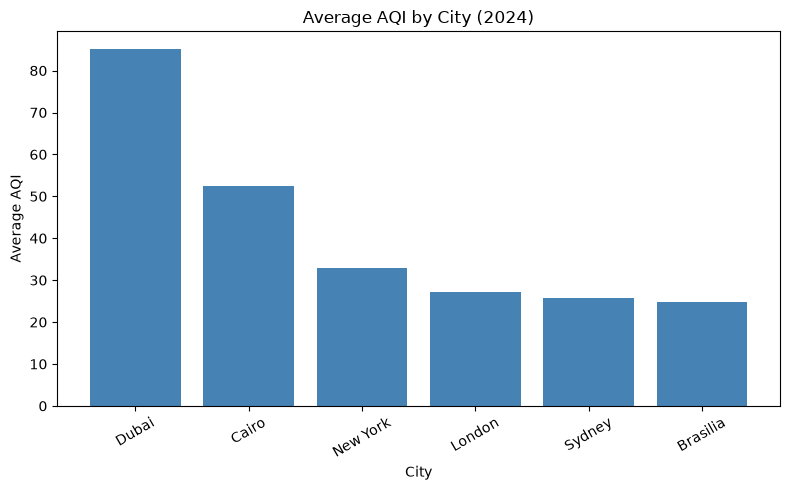

In [35]:
city_order = city_summary.index  # already sorted by AQI, highest first

plt.figure(figsize=(8, 5))
plt.bar(city_order, city_summary["AQI"], color="steelblue")
plt.title("Average AQI by City (2024)")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


Dubai sits well above the other five cities, which matches the `city_summary` table Aishmita built
in Part 2. Brasilia is the cleanest.


**2. AQI trend across the year.**

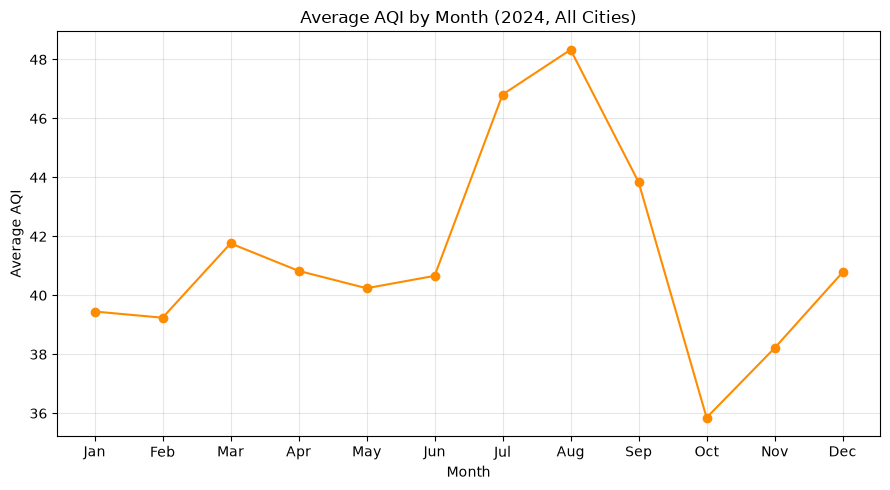

In [36]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9, 5))
plt.plot(month_names, monthly_aqi.values, marker="o", color="darkorange")
plt.title("Average AQI by Month (2024, All Cities)")
plt.xlabel("Month")
plt.ylabel("Average AQI")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


AQI stays in a fairly narrow band all year, with July and August clearly the worst months and
October the cleanest. We used a line chart because this is a trend over time, not a comparison
between separate categories.


**3. PM2.5 versus AQI.**

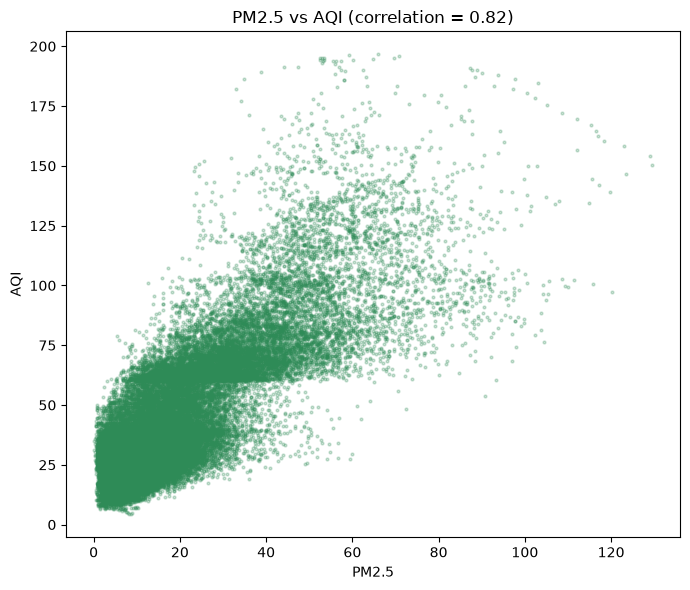

In [37]:
plt.figure(figsize=(7, 6))
plt.scatter(df["PM2.5"], df["AQI"], s=4, alpha=0.25, color="seagreen")
plt.title(f"PM2.5 vs AQI (correlation = {pm25_aqi_corr:.2f})")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()


The upward pattern is obvious just from the shape of the cloud of points, which backs up the 0.82
correlation we calculated with NumPy above.


**4. Average pollutant levels overall.**

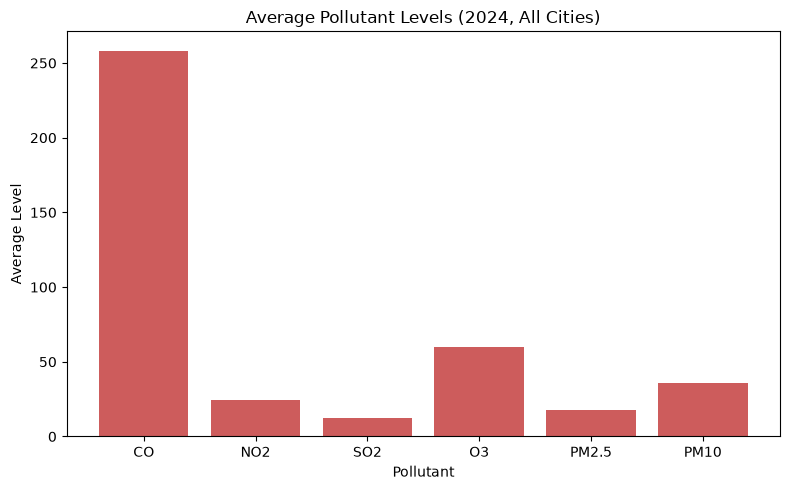

In [38]:
overall_avg = df[["CO", "NO2", "SO2", "O3", "PM2.5", "PM10"]].mean().round(1)

plt.figure(figsize=(8, 5))
plt.bar(overall_avg.index, overall_avg.values, color="indianred")
plt.title("Average Pollutant Levels (2024, All Cities)")
plt.xlabel("Pollutant")
plt.ylabel("Average Level")
plt.tight_layout()
plt.show()


CO sits on a completely different scale from the others, which is just a unit difference (CO is
measured in much larger numbers than PM2.5 or PM10) rather than CO being 10x more "present" in the
air.


# <div style="text-align:center; border-radius:15px 50px; padding:12px; color:white; margin:0; font-size:150%; font-family:Pacifico; background-color: #4B0082; overflow:hidden"><b>Part 3 continued: findings and conclusion</b><div style="font-family:Arial; font-size:58%; color:#d8dcff; margin-top:8px">presented by Anupam</div></div>

## Major findings

Every number below comes from the outputs above, and we checked each one against the printed
result before writing it here.

**1. Dubai has by far the worst air quality, Brasilia the best.**
Dubai averages an AQI of 85.1 across the whole year, well into "Moderate" territory and close to
"Unhealthy for Sensitive Groups." Brasilia averages 24.7, the cleanest of the six, with Sydney
(25.8) and London (27.1) close behind it.

**2. AQI stays fairly steady across the year, with July and August the worst months.**
The monthly average never leaves the 36-48 range, but it clearly peaks in July (46.8) and August
(48.3) and dips lowest in October (35.9).

**3. One event drives almost all of the "Unhealthy" hours in the dataset.**
2,182 of 52,704 hourly readings (4.1%) exceed AQI 100, but every one of the ten worst hours in the
entire dataset happened in Dubai on 18 August 2024. Extreme pollution here is episodic, not evenly
spread through the year.

**4. Particulate matter is strongly linked to AQI.**
PM2.5 correlates with AQI at r = 0.82 and PM10 at r = 0.85. This is a real, confirmed relationship
in the data, but not a causal claim we are testing -- AQI is partly calculated from particulate
readings to begin with, so a strong link here is expected, not a surprise finding.

**5. The missing CO2 data is a monitoring gap, not random noise.**
81.7% of CO2 readings are missing, but not randomly: CO2 monitoring only started on 26 October
2024, identically across all six cities. We chose not to invent 10 months of CO2 data, and only
used it for the window where it was actually measured.

**6. Even inside that short CO2 window, city rankings looked different.**
New York had the highest average CO2 (about 488 ppm) and Sydney the lowest (about 443 ppm) in the
Oct 26 - Dec 31 window -- not the same order as the full-year AQI ranking, which is one more reason
we kept CO2 out of the main city comparison.


## Summary and conclusion

**What we analysed.** 52,704 hourly air-quality readings across six cities (Brasilia, Cairo,
Dubai, London, New York, Sydney) for all of 2024, covering CO, CO2, NO2, SO2, O3, PM2.5, PM10, and
AQI.

**What the work actually involved.** We built this up in the same order the course taught it:
plain variables and operators first (Aaska), then loops and functions applied to a small hand-typed
sample before touching any library, then real file reading with `open()`, and only after all of
that did we bring in Pandas for the full 52,704-row dataset (Aishmita). NumPy and Matplotlib came
last, once there was a clean DataFrame worth visualizing (Anupam).

**What we found.** Dubai is consistently the most polluted city and Brasilia the cleanest. AQI
moves in a fairly narrow band across the year but spikes hard in the Northern Hemisphere summer,
and almost all of the dataset's worst hours trace back to a single mid-August event in Dubai
rather than a general summer trend. Particulate matter (PM2.5 and PM10) is clearly linked to AQI,
which makes sense given how AQI is built.

**What the missing CO2 data taught us.** The biggest data-quality decision in this project was
what to do with a column that is 81.7% empty. Rather than guess, we checked *when* the values were
missing and found a clean answer: CO2 monitoring simply had not started yet for most of the year.
Once we knew that, the right move was obvious -- report the gap honestly, use CO2 only for the
period it actually covers, and keep it out of conclusions about the rest of the year.

**How we split the work.** Aaska's Part 1 built the Python foundation by hand; Aishmita's Part 2
turned that foundation into functions, read the real file, and ran the full Pandas analysis;
Anupam's Part 3 took Aishmita's tables into NumPy and Matplotlib and pulled the whole project
together into the findings above.
